In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"

df = pd.read_csv(CATALOG)

print(f"Total catalog objects: {len(df):,}")

Total catalog objects: 13,922,457


In [2]:
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")

Resolved galaxies: 154,638


In [3]:
resolved["M_star_Msun"] = (
    resolved["M_star"] * 1e10 / 0.6774
)


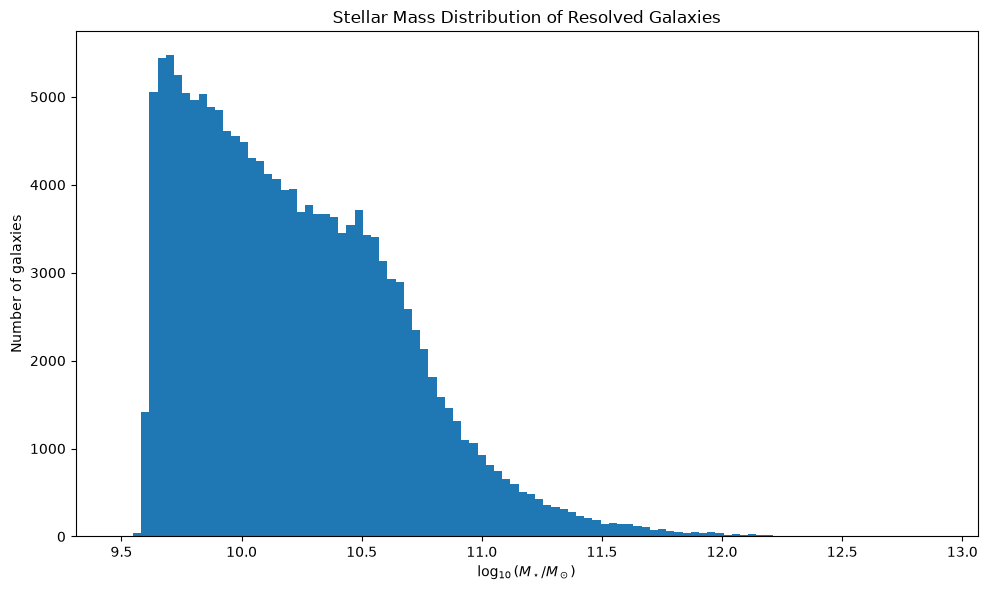

In [4]:
plt.figure(figsize=(10,6))

plt.hist(
    np.log10(resolved["M_star_Msun"]),
    bins=100
)

plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
plt.ylabel("Number of galaxies")
plt.title("Stellar Mass Distribution of Resolved Galaxies")

plt.tight_layout()
plt.show()

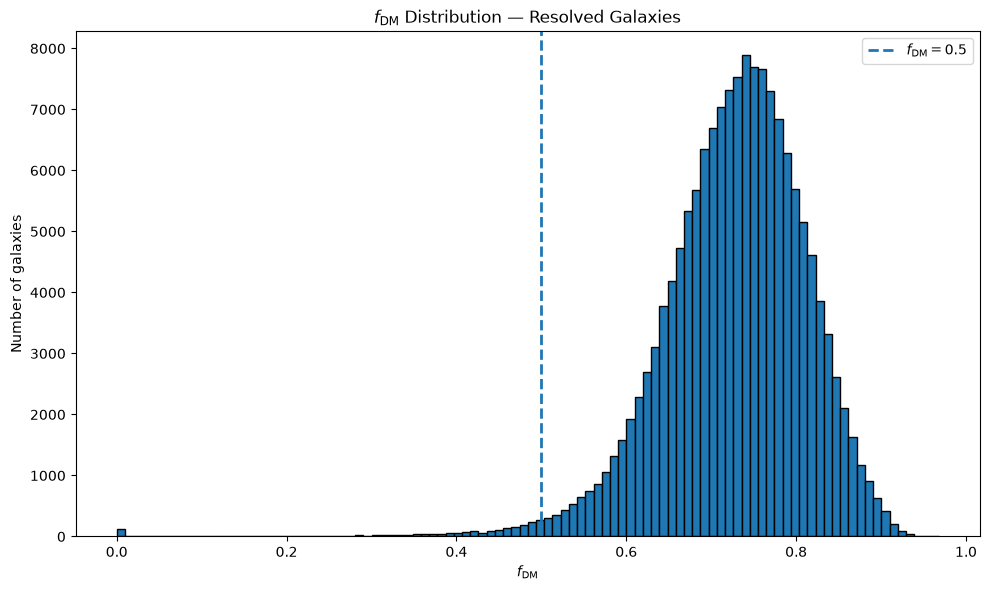

In [5]:
plt.figure(figsize=(10,6))

plt.hist(
    resolved["f_DM"],
    bins=100,
    edgecolor="black"
)

plt.axvline(
    0.5,
    linestyle="--",
    linewidth=2,
    label=r"$f_{\rm DM}=0.5$"
)

plt.xlabel(r"$f_{\rm DM}$")
plt.ylabel("Number of galaxies")
plt.title(r"$f_{\rm DM}$ Distribution — Resolved Galaxies")
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
zero_dm = resolved[resolved["f_DM"] < 0.05].copy()

print(f"f_DM < 0.05: {len(zero_dm):,}")

print("\nStar particles:")
print(zero_dm["N_star"].describe())

print("\nStellar mass:")
print(zero_dm["M_star"].describe())

print("\nDM mass inside 2Rh:")
print(zero_dm["M_DM_2Rh"].describe())

print("\nTotal mass inside 2Rh:")
print(zero_dm["M_total_2Rh"].describe())

f_DM < 0.05: 140

Star particles:
count     140.000000
mean      962.585714
std       716.656545
min       501.000000
25%       610.000000
50%       753.500000
75%       983.750000
max      4943.000000
Name: N_star, dtype: float64

Stellar mass:
count    140.000000
mean       0.471238
std        0.359174
min        0.204604
25%        0.297258
50%        0.361474
75%        0.481520
max        2.482137
Name: M_star, dtype: float64

DM mass inside 2Rh:
count    140.000000
mean       0.002049
std        0.005783
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.035851
Name: M_DM_2Rh, dtype: float64

Total mass inside 2Rh:
count    140.000000
mean       0.420946
std        0.306372
min        0.172574
25%        0.264421
50%        0.339149
75%        0.432087
max        2.061432
Name: M_total_2Rh, dtype: float64


In [8]:
print(
    zero_dm[
        [
            "f_DM",
            "M_DM_2Rh",
            "M_total_2Rh",
            "M_star",
            "N_star",
            "IsSatellite",
            "Host_M200c",
            "r_over_R200c"
        ]
    ].sort_values("f_DM").head(20)
)


       f_DM  M_DM_2Rh  M_total_2Rh    M_star  N_star  IsSatellite  Host_M200c  \
802     0.0       0.0     0.367969  0.417112     871         True  104034.410   
832     0.0       0.0     0.280911  0.351907     817         True  104034.410   
834     0.0       0.0     0.338940  0.400318     816         True  104034.410   
12046   0.0       0.0     0.669930  0.884442    1702         True   88559.220   
12212   0.0       0.0     0.284678  0.346855     789         True   88559.220   
23088   0.0       0.0     0.359758  0.428555     877         True   60943.660   
23096   0.0       0.0     0.322569  0.401060     850         True   60943.660   
23199   0.0       0.0     0.209406  0.272525     589         True   60943.660   
28282   0.0       0.0     0.229773  0.291268     676         True   57024.867   
33564   0.0       0.0     0.209816  0.255331     553         True   49689.145   
37828   0.0       0.0     0.306514  0.383281     860         True   31111.979   
42824   0.0       0.0     0.

In [9]:
n_resolved = len(resolved)
n_dmdg = (resolved["f_DM"] < 0.5).sum()
dmdg_fraction = n_dmdg / n_resolved
print (f"Resolved galaxies: {n_resolved:,}")
print(f"Resolved DMDG candidates (f_DM < 0.5): {n_dmdg:,}")
print(f"Fraction: {dmdg_fraction:.6%}")

Resolved galaxies: 154,638
Resolved DMDG candidates (f_DM < 0.5): 1,947
Fraction: 1.259070%


In [10]:
n_extreme = (resolved["f_DM"] < 0.05).sum()
print(f"Low DMDG quantity: {n_extreme:,}")
print(f"Low DMDG % of Resolved: {n_extreme / n_dmdg:,}")

Low DMDG quantity: 140
Low DMDG % of Resolved: 0.07190549563430919
